# Titanic — Machine Learning from Disaster

**Objective:** Predict which passengers survived the Titanic shipwreck based on demographic and ticket-related features.

**Data:** [Kaggle Titanic Competition](https://www.kaggle.com/competitions/titanic/data)

### Imports and configuration


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

### Data loading

In [41]:
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

# Store the test PassengerId for the future submission.csv file
test_passenger_ids = test["PassengerId"].copy()

print("train shape:", train.shape)
print("test shape:", test.shape)
train.head()

train shape: (891, 12)
test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [43]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### 2. EDA — Which passenger groups survived more frequently

Overall survival rate, followed by a breakdown by key features: sex, class, age, and family presence on board.

In [44]:
overall_rate = train["Survived"].mean()
print(f"Overall survival rate: {overall_rate:.1%} ({train['Survived'].sum()} out of {len(train)} passengers)")

Overall survival rate: 38.4% (342 out of 891 passengers)


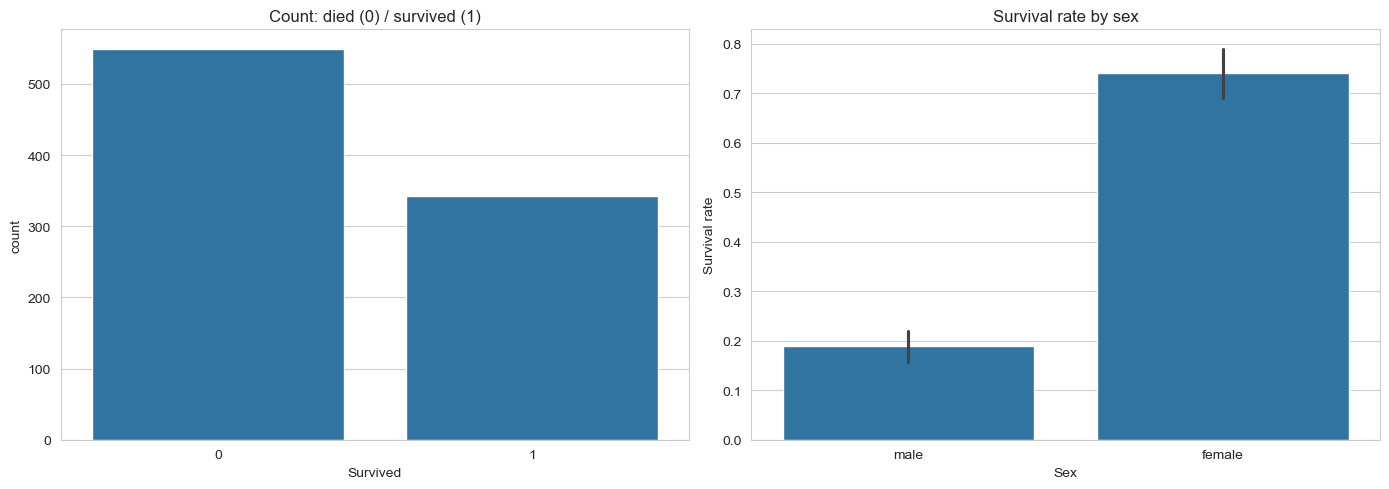

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=train, x="Survived", ax=axes[0])
axes[0].set_title("Count: died (0) / survived (1)")

sns.barplot(data=train, x="Sex", y="Survived", ax=axes[1])
axes[1].set_title("Survival rate by sex")
axes[1].set_ylabel("Survival rate")

plt.tight_layout()
plt.show()

train.groupby("Sex")["Survived"].mean()

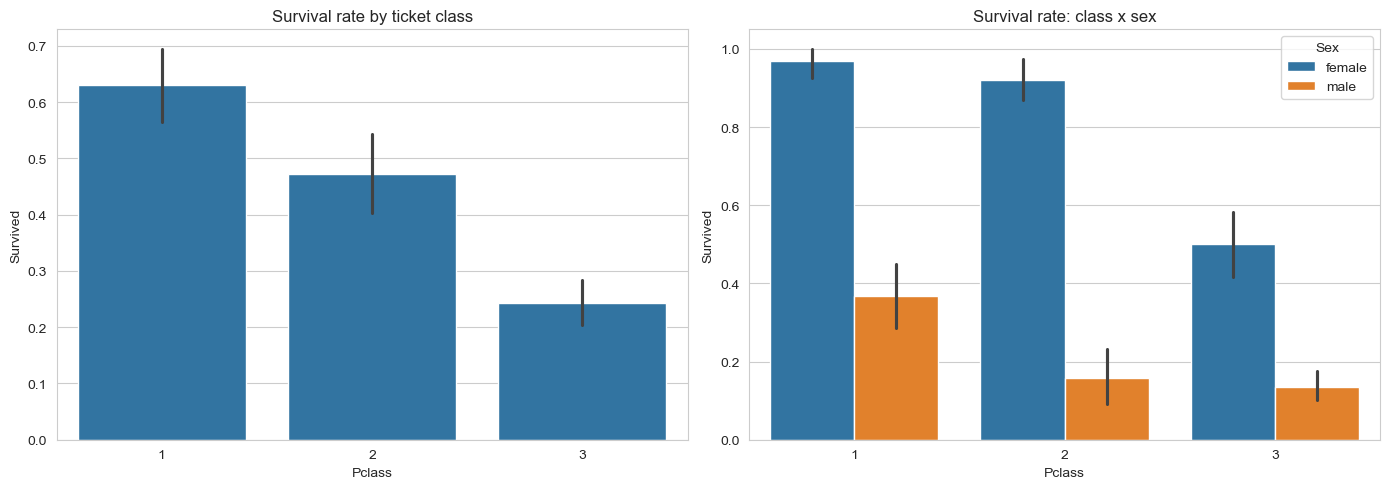

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=train, x="Pclass", y="Survived", ax=axes[0])
axes[0].set_title("Survival rate by ticket class")

sns.barplot(data=train, x="Pclass", y="Survived", hue="Sex", ax=axes[1])
axes[1].set_title("Survival rate: class x sex")

plt.tight_layout()
plt.show()

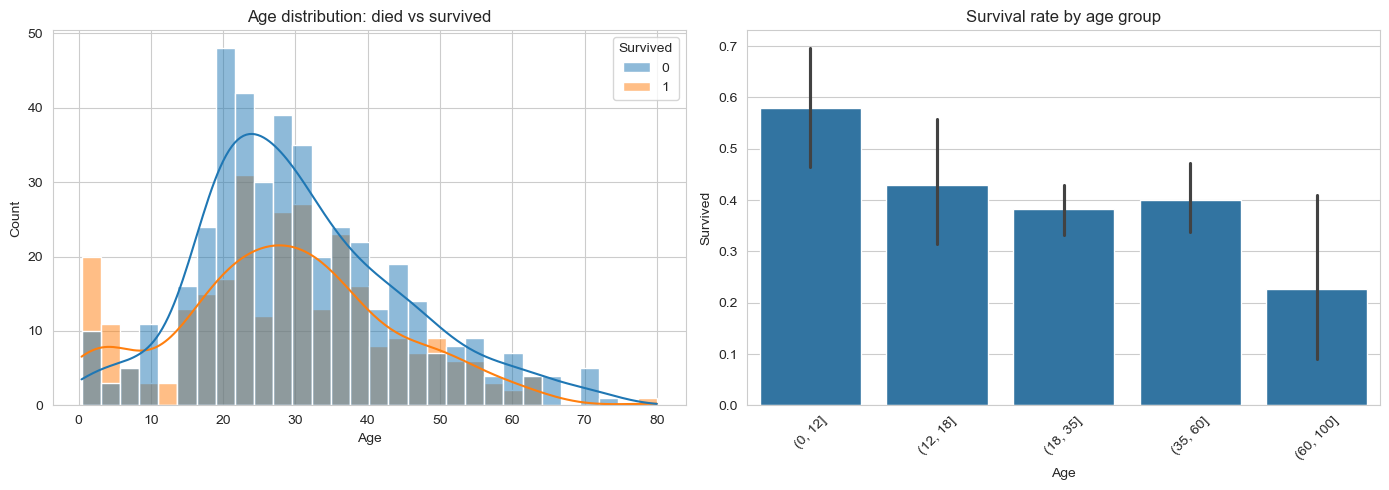

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=train, x="Age", hue="Survived", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age distribution: died vs survived")

age_bins = pd.cut(train["Age"], bins=[0, 12, 18, 35, 60, 100])
sns.barplot(x=age_bins, y=train["Survived"], ax=axes[1])
axes[1].set_title("Survival rate by age group")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

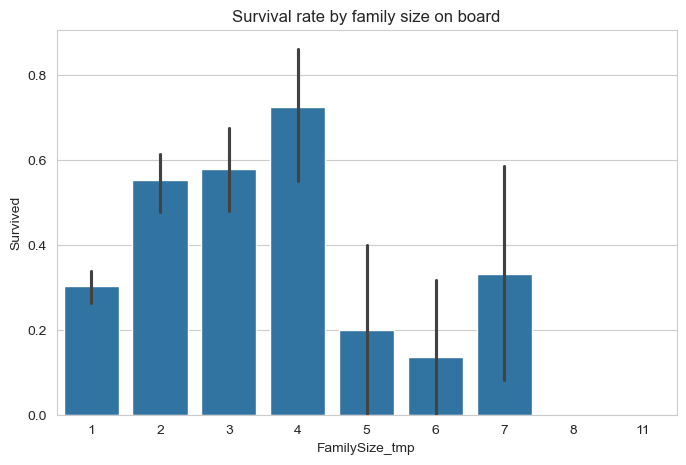

In [48]:
# Family on board: SibSp (spouses/siblings) + Parch (parents/children)
train["FamilySize_tmp"] = train["SibSp"] + train["Parch"] + 1

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=train, x="FamilySize_tmp", y="Survived", ax=ax)
ax.set_title("Survival rate by family size on board")
plt.show()

train.drop(columns="FamilySize_tmp", inplace=True)

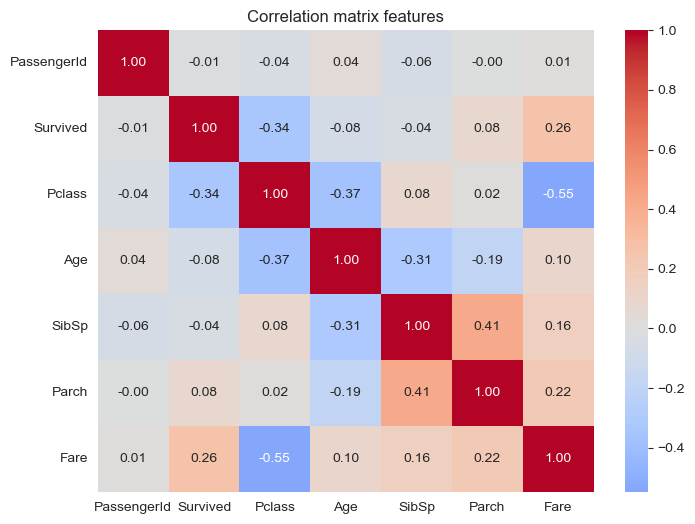

In [49]:
corr = train.select_dtypes(include=np.number).corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix features")
plt.show()

**Interim conclusions from EDA:**

- Women survived at significantly higher rates than men ("women and children first").

- 1st-class passengers had higher survival rates than 2nd- and 3rd-class passengers.

- Children (Age < 12) had elevated chances of survival.

- Single passengers and very large families (5+ members) survived less frequently than medium-sized families (2–4 members).

### 3. Data cleaning

We process train and test together (merge them) to ensure consistent imputation of missing values.

In [50]:
train["is_train"] = 1
test["is_train"] = 0
test["Survived"] = np.nan  # заглушка, чтобы объединить датафреймы

full = pd.concat([train, test], axis=0, ignore_index=True)
print(full.shape)
full.isnull().sum().sort_values(ascending=False)


(1309, 13)


Cabin          1014
Survived        418
Age             263
Embarked          2
Fare              1
Sex               0
Name              0
Pclass            0
PassengerId       0
Ticket            0
Parch             0
SibSp             0
is_train          0
dtype: int64

In [51]:
# --- Title extracted from name, needed both as a feature and for smart Age imputation ---
full["Title"] = full["Name"].str.extract(r",\s*([^.]*)\.")

# Group rare titles
title_map = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "Countess": "Rare", "Capt": "Rare", "Col": "Rare",
    "Don": "Rare", "Dr": "Rare", "Major": "Rare", "Rev": "Rare",
    "Sir": "Rare", "Jonkheer": "Rare", "Dona": "Rare",
}
full["Title"] = full["Title"].replace(title_map)
full["Title"].value_counts()

Title
Mr              757
Miss            264
Mrs             198
Master           61
Rare             28
the Countess      1
Name: count, dtype: int64

In [52]:
# --- Age: impute with group-wise median (by Title and Pclass) — more accurate than global median ---
full["Age"] = full.groupby(["Title", "Pclass"])["Age"].transform(
    lambda x: x.fillna(x.median())
)
full["Age"] = full["Age"].fillna(full["Age"].median())  # fallback for rare combinations

In [53]:
# --- Embarked: impute with mode ---
full["Embarked"] = full["Embarked"].fillna(full["Embarked"].mode()[0])

# --- Fare: impute with median by class ---
full["Fare"] = full.groupby("Pclass")["Fare"].transform(
    lambda x: x.fillna(x.median())
)

# --- Cabin: too many missing values (~77%), convert into a "has cabin" indicator + deck letter ---
full["HasCabin"] = full["Cabin"].notnull().astype(int)
full["Deck"] = full["Cabin"].str[0].fillna("U")  # U = Unknown

In [54]:
print("Remaining missing values (excluding Survived for test):")
full.isnull().sum()[full.isnull().sum() > 0]

Remaining missing values (excluding Survived for test):


Survived     418
Cabin       1014
dtype: int64

### 4. Feature Engineering

In [55]:
# Family size and "alone on board" indicator
full["FamilySize"] = full["SibSp"] + full["Parch"] + 1
full["IsAlone"] = (full["FamilySize"] == 1).astype(int)

full["AgeBin"] = pd.cut(full["Age"], bins=[0, 12, 18, 35, 60, 100],
                         labels=["Child", "Teen", "Adult", "Middle", "Senior"])
full["FareBin"] = pd.qcut(full["Fare"], 4, labels=["Low", "Mid", "High", "VeryHigh"])

full["TicketPrefix"] = full["Ticket"].str.extract(r"([A-Za-z\.\/]+)")[0].fillna("None")

full[["FamilySize", "IsAlone", "AgeBin", "FareBin", "Title", "Deck"]].head()

,FamilySize,IsAlone,AgeBin,FareBin,Title,Deck
0,2,0,Adult,Low,Mr,U
1,2,0,Middle,VeryHigh,Mrs,C
2,1,1,Adult,Mid,Miss,U
3,2,0,Adult,VeryHigh,Mrs,C
4,1,1,Adult,Mid,Mr,U


### 5. Encoding categorical features

In [56]:
features_to_drop = ["Name", "Ticket", "Cabin", "TicketPrefix"]
model_df = full.drop(columns=features_to_drop)

categorical_cols = ["Sex", "Embarked", "Title", "Deck", "AgeBin", "FareBin"]
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

model_df.head()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,is_train,HasCabin,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,AgeBin_Teen,AgeBin_Adult,AgeBin_Middle,AgeBin_Senior,FareBin_Mid,FareBin_High,FareBin_VeryHigh
0,1,0.0,3,22.0,1,0,7.2500,1,0,2,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False
1,2,1.0,1,38.0,1,0,71.2833,1,1,2,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
2,3,1.0,3,26.0,0,0,7.9250,1,0,1,1,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False
3,4,1.0,1,35.0,1,0,53.1000,1,1,2,0,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True
4,5,0.0,3,35.0,0,0,8.0500,1,0,1,1,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False


In [57]:
train_processed = model_df[model_df["is_train"] == 1].drop(columns=["is_train"])
test_processed = model_df[model_df["is_train"] == 0].drop(columns=["is_train", "Survived"])

X = train_processed.drop(columns=["Survived", "PassengerId"])
y = train_processed["Survived"].astype(int)

X_test_final = test_processed.drop(columns=["PassengerId"])

X_test_final = X_test_final.reindex(columns=X.columns, fill_value=0)

print("X:", X.shape, "| y:", y.shape, "| X_test_final:", X_test_final.shape)

X: (891, 31) | y: (891,) | X_test_final: (418, 31)


In [58]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("train:", X_train.shape, " val:", X_val.shape)


train: (712, 31)  val: (179, 31)


### 6. Model training and cross-validation

We compare several baseline algorithms using 5-fold stratified cross-validation before tuning the best-performing one.

In [59]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVC": SVC(probability=True, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"{name:20s} accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

LogisticRegression   accuracy: 0.8175 (+/- 0.0272)
RandomForest         accuracy: 0.8245 (+/- 0.0228)
GradientBoosting     accuracy: 0.8104 (+/- 0.0269)
SVC                  accuracy: 0.6910 (+/- 0.0212)


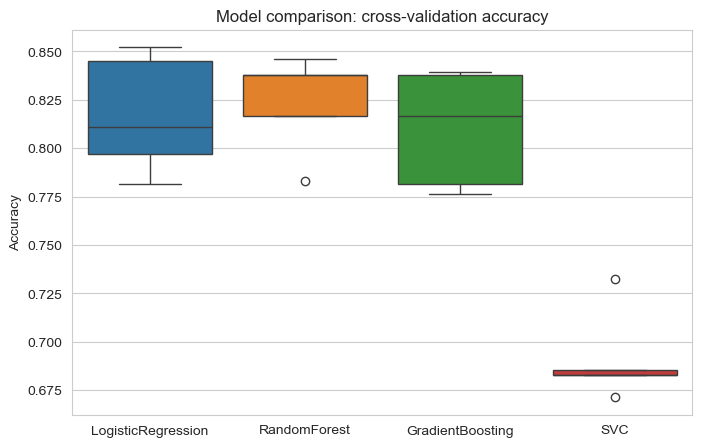

In [62]:
results_df = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
sns.boxplot(data=results_df)
plt.title("Model comparison: cross-validation accuracy")
plt.ylabel("Accuracy")
plt.show()

### 7. Hyperparameter tuning for the best model

In [63]:
param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая CV accuracy:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Лучшая CV accuracy: 0.8343149807938539


### 8. Model evaluation on the hold-out validation set

In [64]:
val_preds = best_model.predict(X_val)
val_proba = best_model.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, val_preds))
print("ROC AUC:", roc_auc_score(y_val, val_proba))
print()
print(classification_report(y_val, val_preds))


Accuracy: 0.7988826815642458
ROC AUC: 0.835243741765481

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



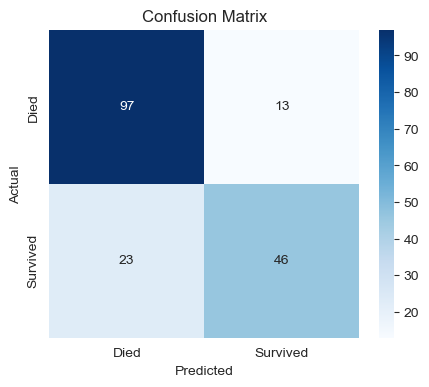

In [65]:
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

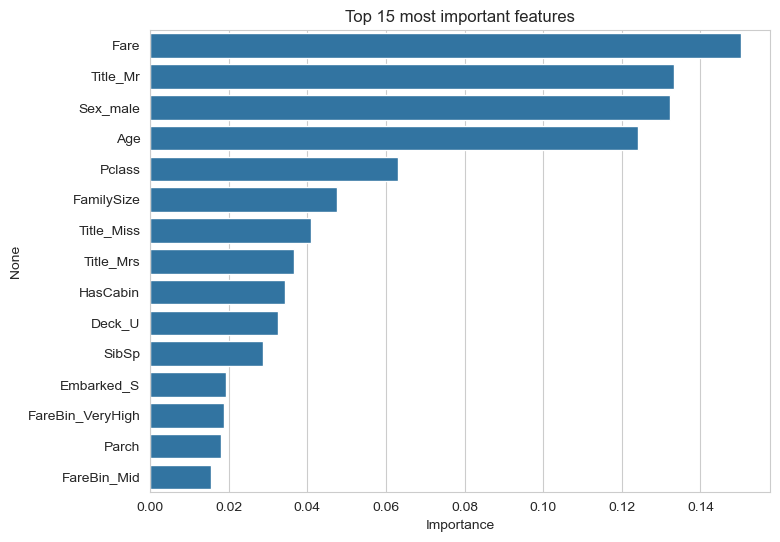

In [66]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 most important features")
plt.xlabel("Importance")
plt.show()

In [68]:
best_model.fit(X, y)

test_predictions = best_model.predict(X_test_final)

submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": test_predictions.astype(int)
})

submission.to_csv("submission.csv", index=False)
print("submission.csv saved, строк:", len(submission))
submission.head()

submission.csv saved, строк: 418


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1
